# __DiploDatos Kaggle Competition__


## Definición del problema

La diabetes es una enfermedad crónica con alta prevalencia a nivel mundial y su detección temprana es clave para reducir complicaciones y mejorar el manejo clínico de los pacientes.

En este proyecto se aborda un problema de **clasificación supervisada** cuyo objetivo es predecir si un paciente presenta diabetes a partir de variables demográficas y clínicas

Dado el contexto médico, el objetivo principal del modelo no es maximizar la accuracy global sino **maximizar el recall**, es decir, minimizar la cantidad de falsos negativos. En un escenario de screening médico, un falso negativo implica no detectar a un paciente con diabetes, lo cual puede tener consecuencias clínicas relevantes.

Por este motivo, el enfoque de evaluación del modelo se centra en métricas sensibles al desbalance de clases y en estrategias que prioricen la detección de casos positivos.

## Descripción del dataset

El dataset utilizado contiene información demográfica y clínica de pacientes y se utiliza para entrenar modelos de clasificación que permitan predecir el riesgo de diabetes.

El conjunto de datos presenta las siguientes características generales:

- aproximadamente **95.000 registros en el conjunto de entrenamiento**
- **5.000 registros en el conjunto de test**
- **10 variables predictoras**
- una variable objetivo binaria (`diabetes`)
- prevalencia aproximada de **8.5 % de casos positivos**

Las variables incluyen información relevante desde el punto de vista clínico y epidemiológico, entre ellas:

- `age`
- `gender`
- `hypertension`
- `heart_disease`
- `smoking_history`
- `bmi`
- `HbA1c_level`
- `blood_glucose_level`

Estas variables combinan información demográfica, antecedentes médicos y mediciones biomédicas que son utilizadas habitualmente en la evaluación del riesgo de diabetes.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, recall_score
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


#path_train_df = r'c:\Users\DELL\Downloads\supervisado-diplodatos2025\diabetes_prediction_dataset_train-labeled.csv'

In [4]:
from google.colab import files

uploaded = files.upload()

Saving diabetes_prediction_dataset_test.csv to diabetes_prediction_dataset_test.csv
Saving diabetes_prediction_dataset_test-patient_vs_diabetes_example.csv to diabetes_prediction_dataset_test-patient_vs_diabetes_example.csv
Saving diabetes_prediction_dataset_train-labeled.csv to diabetes_prediction_dataset_train-labeled (1).csv


In [5]:
train_df = pd.read_csv('diabetes_prediction_dataset_train-labeled.csv')

Comenzamos con el análisis exploratorio

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient              95000 non-null  int64  
 1   gender               95000 non-null  object 
 2   age                  95000 non-null  float64
 3   hypertension         95000 non-null  int64  
 4   heart_disease        95000 non-null  int64  
 5   smoking_history      95000 non-null  object 
 6   bmi                  95000 non-null  float64
 7   HbA1c_level          95000 non-null  float64
 8   blood_glucose_level  95000 non-null  int64  
 9   diabetes             95000 non-null  int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 7.2+ MB


In [7]:
train_df.sample(7)

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
29219,15798,Female,50.0,0,0,never,32.80,6.2,80,0
30034,97823,Female,6.0,0,0,No Info,18.85,5.8,200,0
240,6197,Female,18.0,0,0,not current,26.67,5.8,130,0
92875,79290,Male,28.0,0,0,current,24.60,4.5,160,0
65687,50431,Male,17.0,0,0,No Info,27.32,4.8,145,0
59743,55855,Male,19.0,0,0,No Info,27.32,5.0,90,0
32825,76381,Female,27.0,0,0,current,25.05,6.2,200,0


In [8]:
train_df.describe()

,patient,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000,95000.000000
mean,50016.501389,41.935269,0.075074,0.039463,27.320879,5.527659,138.070537,0.085074
std,28868.357071,22.514788,0.263512,0.194695,6.626335,1.070261,40.739962,0.278993
min,1.000000,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,25021.750000,24.000000,0.000000,0.000000,23.650000,4.800000,100.000000,0.000000
50%,50024.000000,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,75024.250000,60.000000,0.000000,0.000000,29.580000,6.200000,159.000000,0.000000
max,100000.000000,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [9]:
print(train_df.isna().sum().sort_values(ascending=False))

patient                0
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [10]:
for col in train_df.select_dtypes(include=['object', 'string']).columns:
    print(f"\nColumna: {col}")
    print(f"{train_df[col].value_counts(dropna=False, normalize=True)}")


Columna: gender
gender
Female    0.584874
Male      0.414958
Other     0.000168
Name: proportion, dtype: float64

Columna: smoking_history
smoking_history
No Info        0.357453
never          0.351463
former         0.093800
current        0.092853
not current    0.064516
ever           0.039916
Name: proportion, dtype: float64


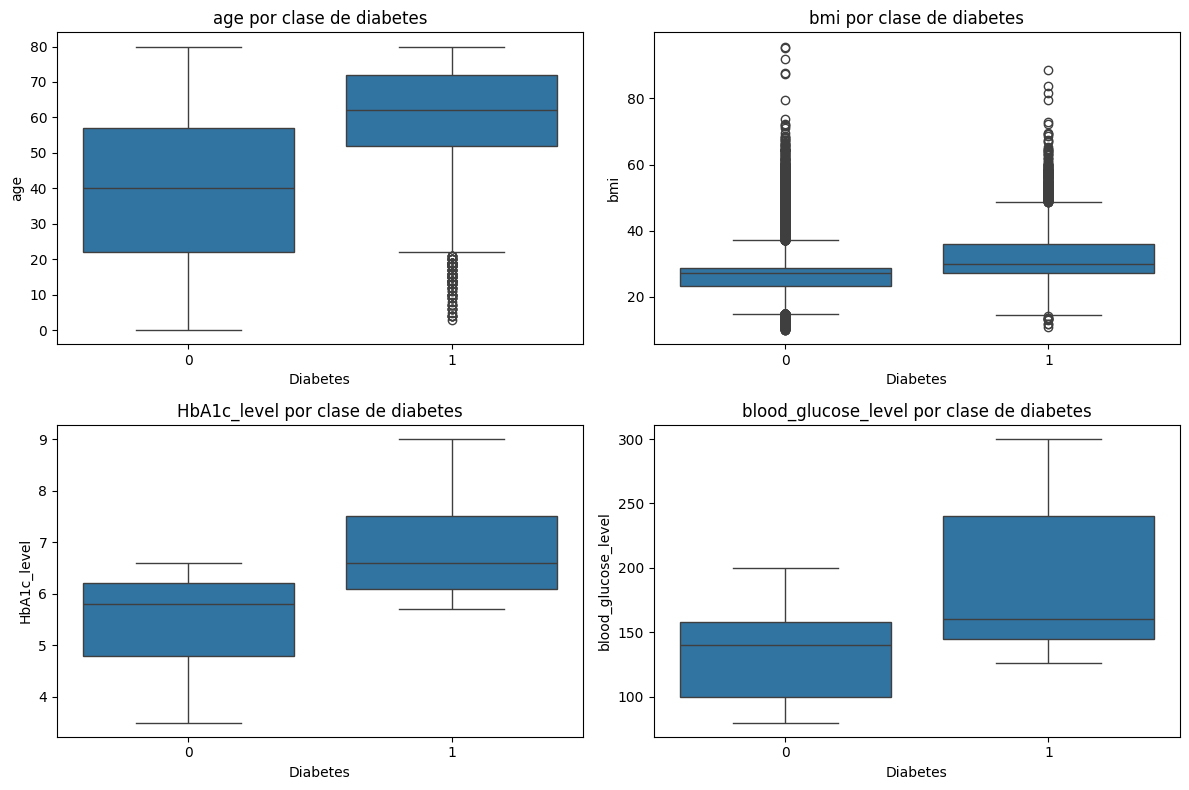

In [11]:
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=train_df['diabetes'], y=train_df[col], ax=axes[i])
    axes[i].set_title(f"{col} por clase de diabetes")
    axes[i].set_xlabel("Diabetes")
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

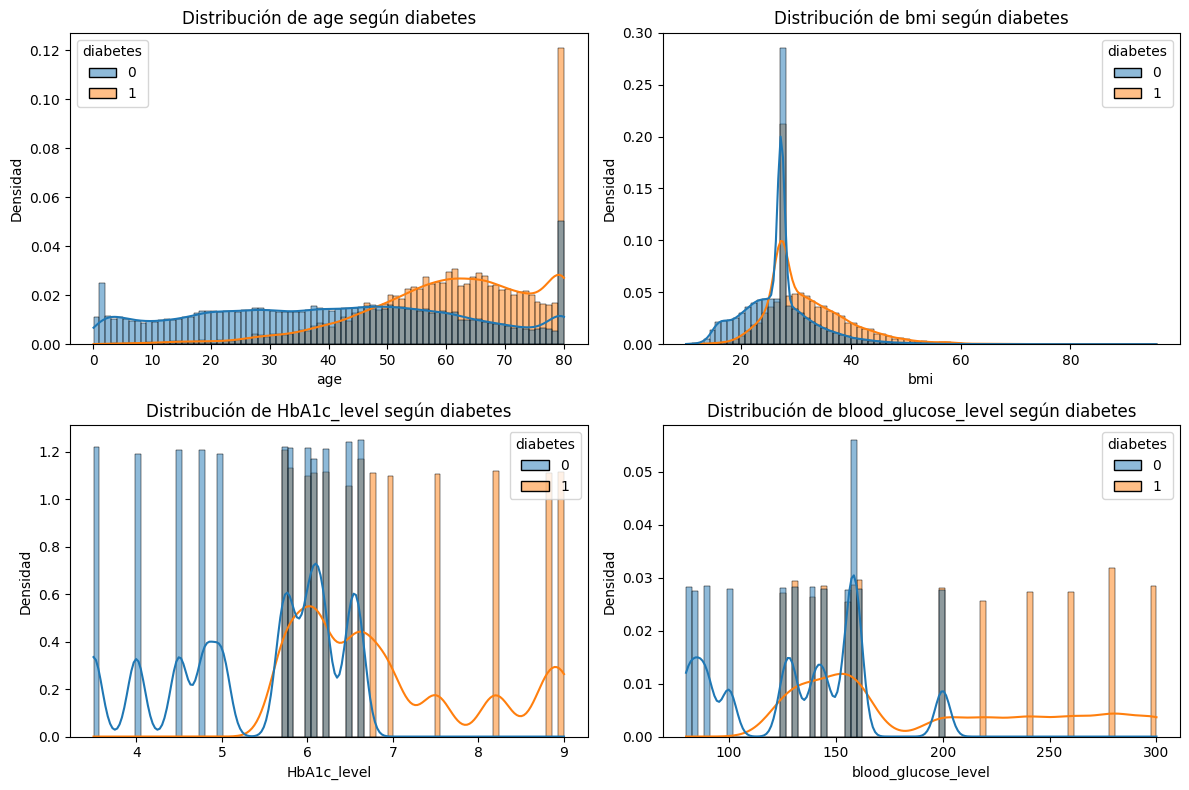

In [12]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols[:len(axes)]):
    sns.histplot(
        data=train_df,
        x=col,
        hue='diabetes',
        bins=80,
        kde=True,
        stat='density',
        common_norm=False,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribución de {col} según diabetes")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Densidad")

plt.tight_layout()
plt.show()

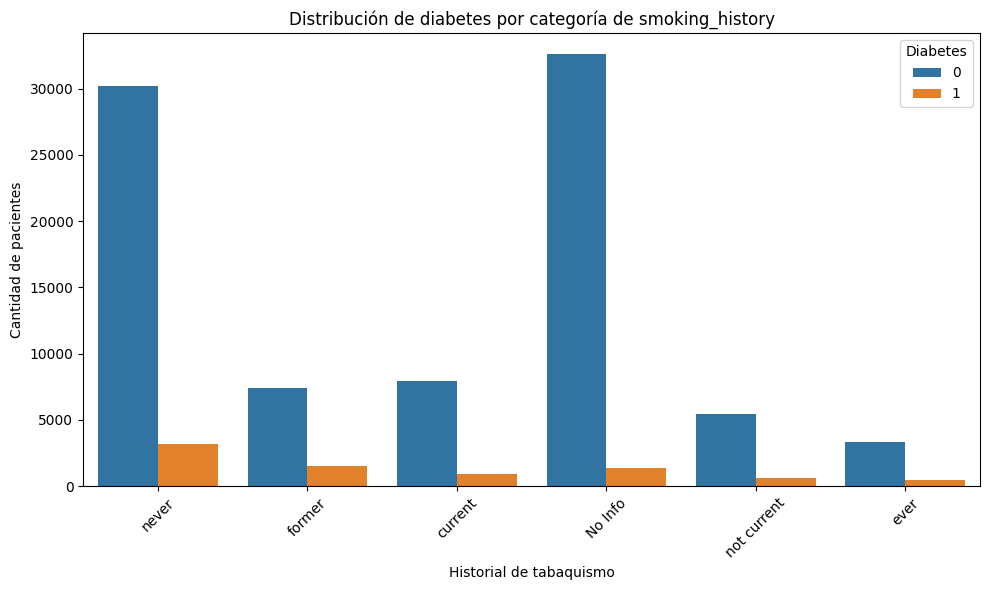

In [13]:

col_smoke = 'smoking_history'
col_target = 'diabetes'

plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x=col_smoke, hue=col_target)
plt.xticks(rotation=45)
plt.title("Distribución de diabetes por categoría de smoking_history")
plt.xlabel("Historial de tabaquismo")
plt.ylabel("Cantidad de pacientes")
plt.legend(title="Diabetes")
plt.tight_layout()
plt.show()

<Axes: xlabel='diabetes'>

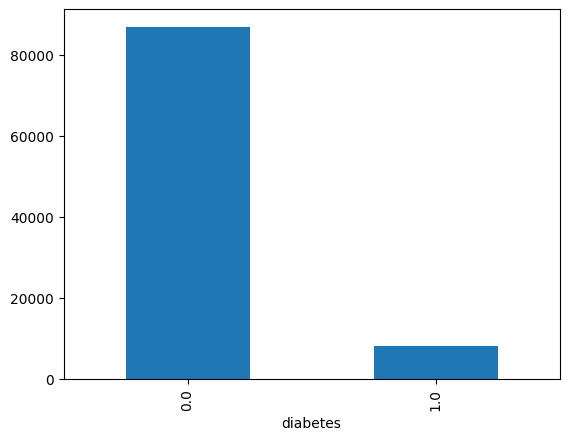

In [14]:
train_df.groupby("patient").diabetes.mean().value_counts().plot(kind='bar')

In [15]:
print(train_df['diabetes'].value_counts(normalize=True))

diabetes
0    0.914926
1    0.085074
Name: proportion, dtype: float64


# Conclusiones de la exploración de los datos

* No hay valores nulos en el dataset.

* La clase objetivo (diabetes) está fuertemente desbalanceada: solo el 8.5% de  los pacientes tiene diabetes.

* Se observaron patrones interesantes:

  * La edad tiene una distribución con picos en personas muy jóvenes y muy mayores. De hecho parece haber un corte en la variable en los 80 años, lo que genera una gran acumulación de filas con en ese valor.

  * El bmi muestra una distribución normal con un pico cerca de 30 (valores repetidos más de 10 mil veces en 27.32), justo en el umbral de obesidad.

  * Observamos que en la feature 'smoking_history', existe una clase llamada 'No info'.

  * En la columna de género existe una clase con muy poca cantidad de valores.

# Criterios para el   `curado` y la `limpieza` del set de datos

* Se tomará un rango de edad que no incluya al valor de 80. Para evitar sesgar el modelo con la gran repetición de filas con este valor, ya que consideramos que es una de las features más importantes.

* Con una repetición aproximada de 22000 veces del valor `27.32`, muestra un comportamiento de imputado artificial más que de datos reales, por ende optamos por quitar estas filas, si bien se pierde una gran cantidad de información, consideramos que aún quedan suficientes filas para lograr entrenar bien el modelo.

* La clase `No info` en la columna `smoking_history`, presenta un comportamiento similar a las personas que nunca fumaron. Se puede interpretar o qué las personas optan por no decir si fuman o no, o también como que dejaron sin responder porque no fuman. Al no presentar un comportamiento extraño decidimos dejarla para el entrenamiento del modelo.

* Respecto a la clase `Other` en `Gender`, si bien tiene pocas filas, consideramos correcto dejarla.

* Debemos transformar las variables categóricas `Gender` y `Smoking_history` para que puedan ser utilizadas en el modelo.

* Realizaremos una categorización de la variable bmi para tratar a la clase en clusters y no como una variable continua. Con objetivo que el modelo puntualice sobre aquellos casos con bmi en extremos. Para esto nos regiremos en la norma que determina las categorías según el nivel de bmi.

* Eliminaremos la columna `patient` ya que es un id que identifica al paciente y no es necesario a la hora de entrenar el modelo.

In [16]:
# Limpieza y curado

def clean_df(df):
    df = df.copy()

    df = df[df['age'] < 80]
    df = df[df['bmi'] != 27.32]

    df['gender'] = df['gender'].map({'Female': 0, 'Male': 1, 'Other': 2})

    df['smoking_history'] = df['smoking_history'].astype(str)
    df['smoking_history'] = LabelEncoder().fit_transform(df['smoking_history'])

    # Categoría de BMI
    def categorizar_bmi(bmi):
        if bmi < 18.5:
            return 'Underweight'
        elif bmi < 25:
            return 'Normal'
        elif bmi < 30:
            return 'Overweight'
        else:
            return 'Obese'

    df['bmi_category'] = df['bmi'].map(categorizar_bmi)

    categoria_a_numero = {
        'Underweight': 0,
        'Normal': 1,
        'Overweight': 2,
        'Obese': 3
    }
    df['bmi_category'] = df['bmi_category'].map(categoria_a_numero)

    return df


train_df_new = clean_df(train_df)

cant_reducida_bmi = train_df_new.shape[0]
total_original = train_df.shape[0]

print(f"Cantidad final:  {cant_reducida_bmi}")
print(f"Cantidad original:  {total_original}")
print(f"Filas perdidas:  {(total_original-cant_reducida_bmi)}")

Cantidad final:  67228
Cantidad original:  95000
Filas perdidas:  27772


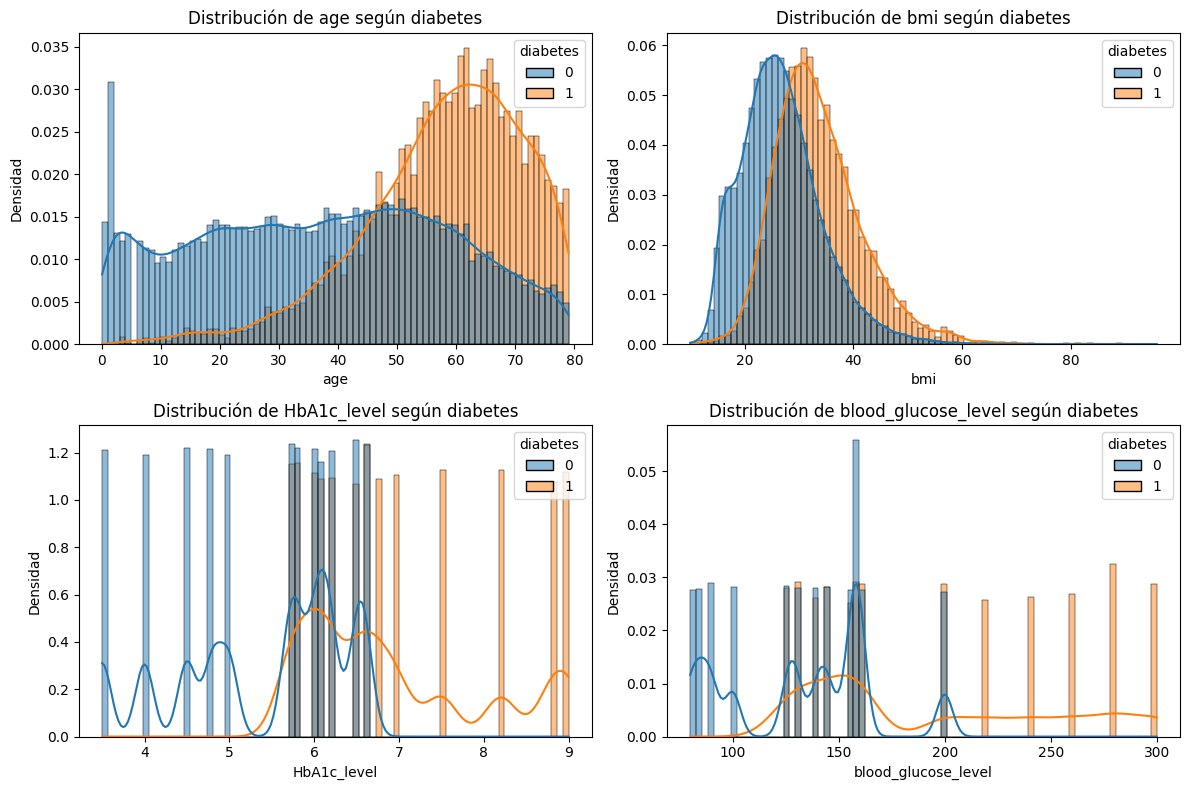

In [17]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols[:len(axes)]):
    sns.histplot(
        data=train_df_new,
        x=col,
        hue='diabetes',
        bins=80,
        kde=True,
        stat='density',
        common_norm=False,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribución de {col} según diabetes")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Densidad")

plt.tight_layout()
plt.show()

In [18]:
print(train_df_new['age'].value_counts().head(10))

age
51.0    1170
47.0    1107
52.0    1101
48.0    1101
57.0    1094
53.0    1089
49.0    1077
55.0    1071
54.0    1060
62.0    1058
Name: count, dtype: int64


Notamos que las distribuciones de las features que se modificaron ahora no presentan anomalías en sus datos. Por ende avanzamos a la etapa de entrenamiento del modelo.

# Recall_score

Es necesario usar recall_score como métrica ya que:

* El objetivo es detectar correctamente a los pacientes con diabetes, minimizando los falsos negativos.
* En problemas médicos, es peor no detectar un caso de diabetes (falso negativo) que detectarlo por error (falso positivo).

* Un falso negativo puede implicar que una persona no reciba tratamiento a tiempo, con consecuencias graves.

* El recall mide justamente esto:
  * Qué proporción de personas con diabetes son correctamente identificadas por el modelo

In [19]:
y = train_df_new.diabetes
X = train_df_new.drop('diabetes', axis=1)


In [20]:
X = X.drop(columns=['patient','bmi'])
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67228 entries, 0 to 94998
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               67228 non-null  int64  
 1   age                  67228 non-null  float64
 2   hypertension         67228 non-null  int64  
 3   heart_disease        67228 non-null  int64  
 4   smoking_history      67228 non-null  int64  
 5   HbA1c_level          67228 non-null  float64
 6   blood_glucose_level  67228 non-null  int64  
 7   bmi_category         67228 non-null  int64  
dtypes: float64(2), int64(6)
memory usage: 4.6 MB


In [21]:
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state = 8, stratify=y)

In [22]:
y_test.info()

<class 'pandas.core.series.Series'>
Index: 13446 entries, 8534 to 7008
Series name: diabetes
Non-Null Count  Dtype
--------------  -----
13446 non-null  int64
dtypes: int64(1)
memory usage: 210.1 KB


# Prueba de distintos modelos

Con el fin de mejorar el rendimiento del baseline proporcionado y encontrar un modelo que maximice el recall, se probaron tres algoritmos clásicos de clasificación sobre datos tabulares:

* **Árbol de Decisión** (DecisionTreeClassifier)

* **Random Forest** (RandomForestClassifier)

* **XGBoost** (XGBClassifier)

Procedemos de la siguiente manera:

* Entrenamiento del modelo correspondiente.

* Evaluación del modelo utilizando validación estratificada (80% entrenamiento / 20% validación) y recall_score como métrica principal, tal como lo exige la competencia.

# Árbol de decisión

In [23]:
clfs = [DecisionTreeClassifier(class_weight='balanced', random_state=8, max_depth=5)]
names = ['Árbol de decisión']

trained_models = []
accuracy_models = []
for clf,name in zip(clfs,names):
    print(name)
    clf.fit(x_train, y_train)
    train_predictions = clf.predict(x_train)
    recall = recall_score(y_train, train_predictions)
    print(f"Recall train {name}: %.2f%%" % (recall * 100.0))

    train_predictions = clf.predict(x_test)
    recall = recall_score(y_test, train_predictions)
    print(f"Recall test {name}: %.2f%%" % (recall * 100.0))
    # plot_confusion_matrix(clf,x_test,y_test)
    trained_models.append(clf)
    accuracy_models.append(recall*100)



Árbol de decisión
Recall train Árbol de decisión: 95.82%
Recall test Árbol de decisión: 95.48%


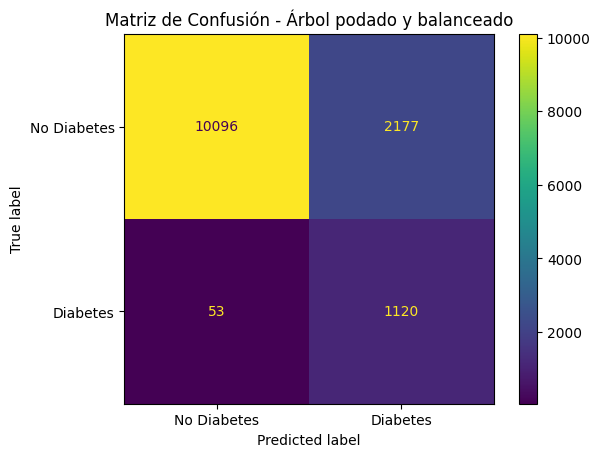

In [24]:
cm = confusion_matrix(y_test, clf.predict(x_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(values_format='d')
plt.title("Matriz de Confusión - Árbol podado y balanceado")
plt.show()

# Random Forest

Random Forest Recall: 0.6974


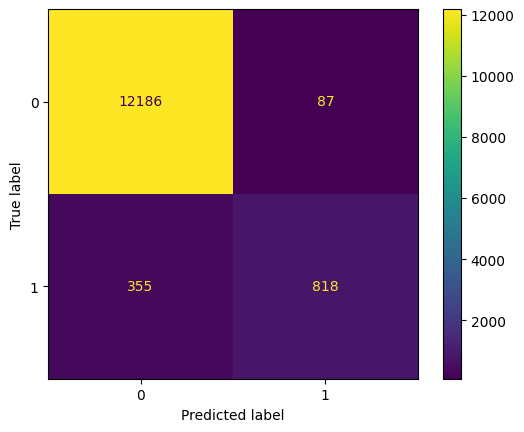

In [25]:
clf_rf = RandomForestClassifier(random_state=8)
clf_rf.fit(x_train, y_train)
pred_rf = clf_rf.predict(x_test)
recall_rf = recall_score(y_test, pred_rf)
print(f"Random Forest Recall: {recall_rf:.4f}")
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf)
plt.show()

Recall muy pobre, incluso sería mejor quedarnos con el modelo de árbol.

# XGBoost

Se probó el entrenamiento con múltiples combinaciones. Usando GridSearchCV. Dejamos transcripta solamente la configuración con el mejor resultado para no aumentar la demora de ejecución a la hora de corregir el notebook.

In [26]:
#Parámetros testeados

ratio = y_train.value_counts()[0] / y_train.value_counts()[1]

param_grid = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'scale_pos_weight': [ratio, ratio * 1.5, ratio * 2],
    'colsample_bytree': [0.3, 0.5],
    'subsample': [0.8, 1.0]
}

In [27]:
xgb_base = XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=8
)

param_grid = {
    'max_depth': [3],
    'learning_rate': [0.01],
    'n_estimators': [100],
    'scale_pos_weight': [ratio, ratio * 1.5, ratio * 2],
    'colsample_bytree': [0.3],
    'subsample': [0.8]
}

grid = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(x_train, y_train)

print("Mejores hiperparámetros:")
print(grid.best_params_)


y_pred_best = grid.best_estimator_.predict(x_test)
print(classification_report(y_test, y_pred_best))


Fitting 3 folds for each of 3 candidates, totalling 9 fits


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [01:22:04] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mejores hiperparámetros:
{'colsample_bytree': 0.3, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': np.float64(20.929865700277126), 'subsample': 0.8}
              precision    recall  f1-score   support

           0       1.00      0.44      0.61     12273
           1       0.14      1.00      0.25      1173

    accuracy                           0.49     13446
   macro avg       0.57      0.72      0.43     13446
weighted avg       0.92      0.49      0.58     13446



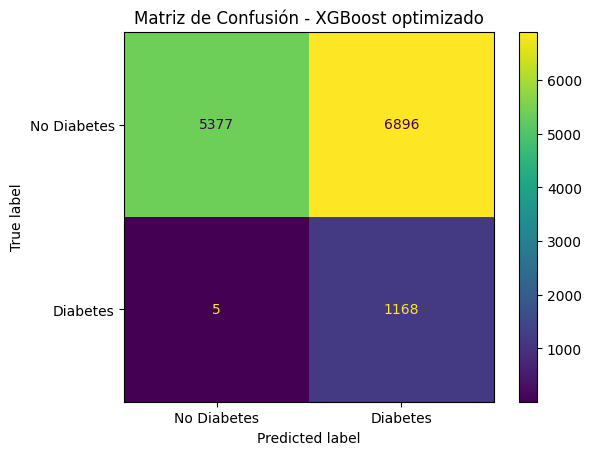

In [28]:
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(values_format='d')  # 'd' = formato entero
plt.title("Matriz de Confusión - XGBoost optimizado")
plt.show()

Vemos que si bien este modelo devuelve muchos Falsos Positivos, el objetivo de reducir los Falsos Negativos se cumple casi a la perfección. Por ende consideramos que este es el modelo que utilizaremos para los datos de la competencia.

# Validación con set de datos reales

In [29]:
path_test = r'diabetes_prediction_dataset_test.csv'

test_df = pd.read_csv(path_test)

In [30]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient              5000 non-null   int64  
 1   gender               5000 non-null   object 
 2   age                  5000 non-null   float64
 3   hypertension         5000 non-null   int64  
 4   heart_disease        5000 non-null   int64  
 5   smoking_history      5000 non-null   object 
 6   bmi                  5000 non-null   float64
 7   HbA1c_level          5000 non-null   float64
 8   blood_glucose_level  5000 non-null   int64  
 9   diabetes             0 non-null      float64
dtypes: float64(4), int64(4), object(2)
memory usage: 390.8+ KB


In [31]:
def clean_df_without_filters(df):
    df = df.copy()

    df['gender'] = df['gender'].map({'Female': 0, 'Male': 1, 'Other': 2})

    df['smoking_history'] = df['smoking_history'].astype(str)
    df['smoking_history'] = LabelEncoder().fit_transform(df['smoking_history'])

    # Categoría de BMI
    def categorizar_bmi(bmi):
        if bmi < 18.5:
            return 'Underweight'
        elif bmi < 25:
            return 'Normal'
        elif bmi < 30:
            return 'Overweight'
        else:
            return 'Obese'

    df['bmi_category'] = df['bmi'].map(categorizar_bmi)

    categoria_a_numero = {
        'Underweight': 0,
        'Normal': 1,
        'Overweight': 2,
        'Obese': 3
    }
    df['bmi_category'] = df['bmi_category'].map(categoria_a_numero)

    return df

In [32]:
X_real = clean_df_without_filters(test_df)
X_real = X_real.drop(columns=['patient','bmi','diabetes'])
X_real.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               5000 non-null   int64  
 1   age                  5000 non-null   float64
 2   hypertension         5000 non-null   int64  
 3   heart_disease        5000 non-null   int64  
 4   smoking_history      5000 non-null   int64  
 5   HbA1c_level          5000 non-null   float64
 6   blood_glucose_level  5000 non-null   int64  
 7   bmi_category         5000 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 312.6 KB


In [33]:
y_real_pred = grid.best_estimator_.predict(X_real)

In [34]:
y_real_pred

array([1, 1, 1, ..., 1, 0, 0])

In [35]:
resultado = test_df.loc[X_real.index, ['patient']].copy()
resultado['diabetes'] = y_real_pred

In [36]:
resultado

,patient,diabetes
0,49267,1
1,82280,1
2,33216,1
3,94551,0
4,43760,1
...,...,...
4995,88540,0
4996,26701,0
4997,47271,1
4998,97941,0


In [ ]:
# Guardar CSV final para entrega
resultado.to_csv('diabetes_con_predicción_grupo_36.csv', index=False, sep=',')